# Stage-count sweep on the frozen magnet crossing

**How many Gauss-Legendre stages does the one-step network need across the LHCb magnet, and
what actually limits its accuracy?**

The network solves one giant implicit Runge-Kutta step from z = 2648.2 mm to z = 7826.0 mm
in a single shot. Instead of a root-finder iterating on the stage states, a 4x50 fp64
network reads the input state and outputs all `q` stage states plus the endpoint, and the
**physics loss** asks that those outputs satisfy the Runge-Kutta relations for the LHCb
equation of motion. `q`, the number of stages, is the one thing varied here: q = 2, 4, 8,
16, on the same population, the same leg, the same optimiser protocol, three seeds each,
in both training modes - the physics loss and its supervised **data twin**, which is the
identical network trained instead on precomputed fp64 RK4 labels.

Three reference levels are plotted beside the networks, and the experiment is really about
which of them is doing the limiting:

* **the exact scheme.** The same q-stage equations solved directly with a root-finder in
  fp64, to a residual below 1e-8. Its endpoint error against the fp64 RK4 reference is the
  error of the *equations*, quite apart from who solves them. A network trained to satisfy
  those equations, and succeeding, lands here - so this curve is the accuracy ceiling of
  the physics loss at each q. Small q means a coarse scheme and a high ceiling.
* **the data twin.** Its labels are the true RK4 states, so it never sees the scheme at
  all. Whatever floor it reaches is the network's own representational and optimisation
  limit on this leg, with the discretisation removed from the picture.
* **the straight line.** Ignoring the magnet entirely and continuing along the input slope
  through the same leg. This is what doing nothing costs, and it is the same number,
  520 mm, for every q.

This notebook only *loads* what the scripts wrote. Nothing here retrains or re-scores.

In [1]:
import glob, json, os
import pandas as pd
from IPython.display import Image, display

RESULTS, FIGURES = "results", "figures"
pd.set_option("display.width", 160)

summary = pd.read_csv(os.path.join(RESULTS, "summary.csv"))
stages = pd.read_csv(os.path.join(RESULTS, "error_vs_stages.csv"), comment="#")
print("runs recorded:", len(summary), "  converged:", int(summary["converged"].sum()))
summary[["q", "mode", "seed", "test_endpoint_med_um", "test_stage_med_um",
         "restarts", "converged", "final_loss"]].round(1)

runs recorded: 24   converged: 24


,q,mode,seed,test_endpoint_med_um,test_stage_med_um,restarts,converged,final_loss
0,2,data,0,174.2,278.4,79,True,0.0
1,2,data,1,168.1,237.5,80,True,0.0
2,2,data,2,222.5,316.8,105,True,0.0
3,2,physics,0,5199.4,16218.3,89,True,0.0
4,2,physics,1,5202.0,16182.0,84,True,0.0
5,2,physics,2,5218.4,16180.6,99,True,0.0
6,4,data,0,181.4,258.1,85,True,0.0
7,4,data,1,156.8,230.4,95,True,0.0
8,4,data,2,181.0,262.4,85,True,0.0
9,4,physics,0,5393.9,5428.5,154,True,0.0


## 1. The datasets

One dataset per q, all four built by `build_datasets.py` from the same official-sample
population and the same fiducial requirement (the reference trajectory must stay inside
the field map). The split counts must therefore be identical across q - that cut asks a
question about the leg and the field, not about how many planes the leg is sampled on -
and the q = 8 file must reproduce the verified `S2b_One_step_network_v2` dataset array for
array, because that is the file the baseline result was trained on.

In [2]:
for p in sorted(glob.glob(os.path.join(RESULTS, "dataset_check_q*.json"))):
    c = json.load(open(p))
    line = "q=%-3d counts %s  match=%s" % (c["q"], c["counts"], c["counts_match"])
    if "bitwise_equal_to_v2_baseline" in c:
        line += "   |  all %d baseline arrays bitwise identical: %s" % (
            c["bitwise_report"]["n_shared_keys"], c["bitwise_equal_to_v2_baseline"])
    print(line)

q=2   counts {'test': 2018, 'train': 1979, 'val': 2062}  match=True
q=4   counts {'test': 2018, 'train': 1979, 'val': 2062}  match=True
q=8   counts {'test': 2018, 'train': 1979, 'val': 2062}  match=True   |  all 16 baseline arrays bitwise identical: True
q=16  counts {'test': 2018, 'train': 1979, 'val': 2062}  match=True


## 2. Where the ceiling really is

The ceiling quoted when this experiment was planned came from
`../Simple_first_pass/results/scheme_error_vs_q.csv`: about 14 mm at q = 2 and 4.3 mm at
q = 4 on leg B. Those numbers were measured on a **different sample** - 32 leg-B legs drawn
*stratified in momentum*, which deliberately over-weights the soft, hard-bending tracks,
each on its own start plane rather than rebased to a common one.

The networks here are scored on the 2018 test states of the frozen leg. Comparing a median
over one population with a median over another is not a comparison at all, and the whole
verdict turns on it, so `measure_scheme_ceiling.py` solves the same scheme again on the
network's own test states, with the solver **imported** from `S1_Simple_first_pass` rather
than copied, and under the same error measure `_shared/evaluate.py` uses -
max(|dx|, |dy|) against the same fp64 RK4 reference.

In [3]:
ceil = pd.DataFrame([json.load(open(p)) for p in sorted(
    glob.glob(os.path.join(RESULTS, "scheme_ceiling_same_population_q*.json")))])
ceil = ceil.sort_values("q")[["q", "n", "converged_frac", "endpoint_med_um",
                              "endpoint_p95_um", "stage_med_um", "wall_s"]]
ceil.insert(len(ceil.columns), "stratified_32_legs_um",
            stages.sort_values("q")["scheme_stratified_endpoint_med_um"].values)
ceil.round(2)

,q,n,converged_frac,endpoint_med_um,endpoint_p95_um,stage_med_um,wall_s,stratified_32_legs_um
0,2,2018,1.0,5198.15,37728.18,15556.64,16.4,14103.61
1,4,2018,1.0,5401.43,54057.39,1138.36,22.5,4297.01
2,8,2018,1.0,22.54,1609.90,10.53,35.0,29.07
3,16,2018,1.0,19.50,325.24,5.81,61.2,37.50


The root-finder converged on essentially every leg at every q (residual < 1e-8), so these
are genuine solutions of the discrete equations - they are simply far from the ODE solution
at small q.

Two things to take from this table. First, on this population the ceiling at q = 2 and
q = 4 is about **5.2 and 5.4 mm**, not the 14 and 4.3 mm of the stratified sample: the
stratified sample is harder at q = 2 and easier at q = 4, and neither number transfers.
Second, and more interesting, **q = 4 is no better than q = 2** here. A q-stage
Gauss-Legendre scheme is formally of order 2q, but that is an asymptotic statement about
small steps; one step of 5178 mm straight through the magnet is nowhere near that regime,
so the extra stages buy nothing until there are enough of them to resolve the field along
the leg. Between q = 4 and q = 8 they suddenly do, and the ceiling falls by more than two
orders of magnitude, to 23 um.

## 3. Error against the number of stages

Now the experiment in one table: for each q, the median over the three seeds and the
seed-to-seed spread for both losses, beside the like-for-like ceiling.

In [4]:
cols = ["q",
        "physics_endpoint_med_um", "physics_endpoint_min_um", "physics_endpoint_max_um",
        "data_endpoint_med_um", "data_endpoint_min_um", "data_endpoint_max_um",
        "scheme_endpoint_med_um", "straight_med_um"]
stages[cols].round(1)

,q,physics_endpoint_med_um,physics_endpoint_min_um,physics_endpoint_max_um,data_endpoint_med_um,data_endpoint_min_um,data_endpoint_max_um,scheme_endpoint_med_um,straight_med_um
0,2,5202.0,5199.4,5218.4,174.2,168.1,222.5,5198.2,520444.4
1,4,5371.0,5351.8,5393.9,181.0,156.8,181.4,5401.4,520444.3
2,8,180.9,164.7,240.1,176.0,161.8,204.1,22.5,520444.3
3,16,187.4,185.7,279.6,169.7,146.9,176.1,19.5,520444.3


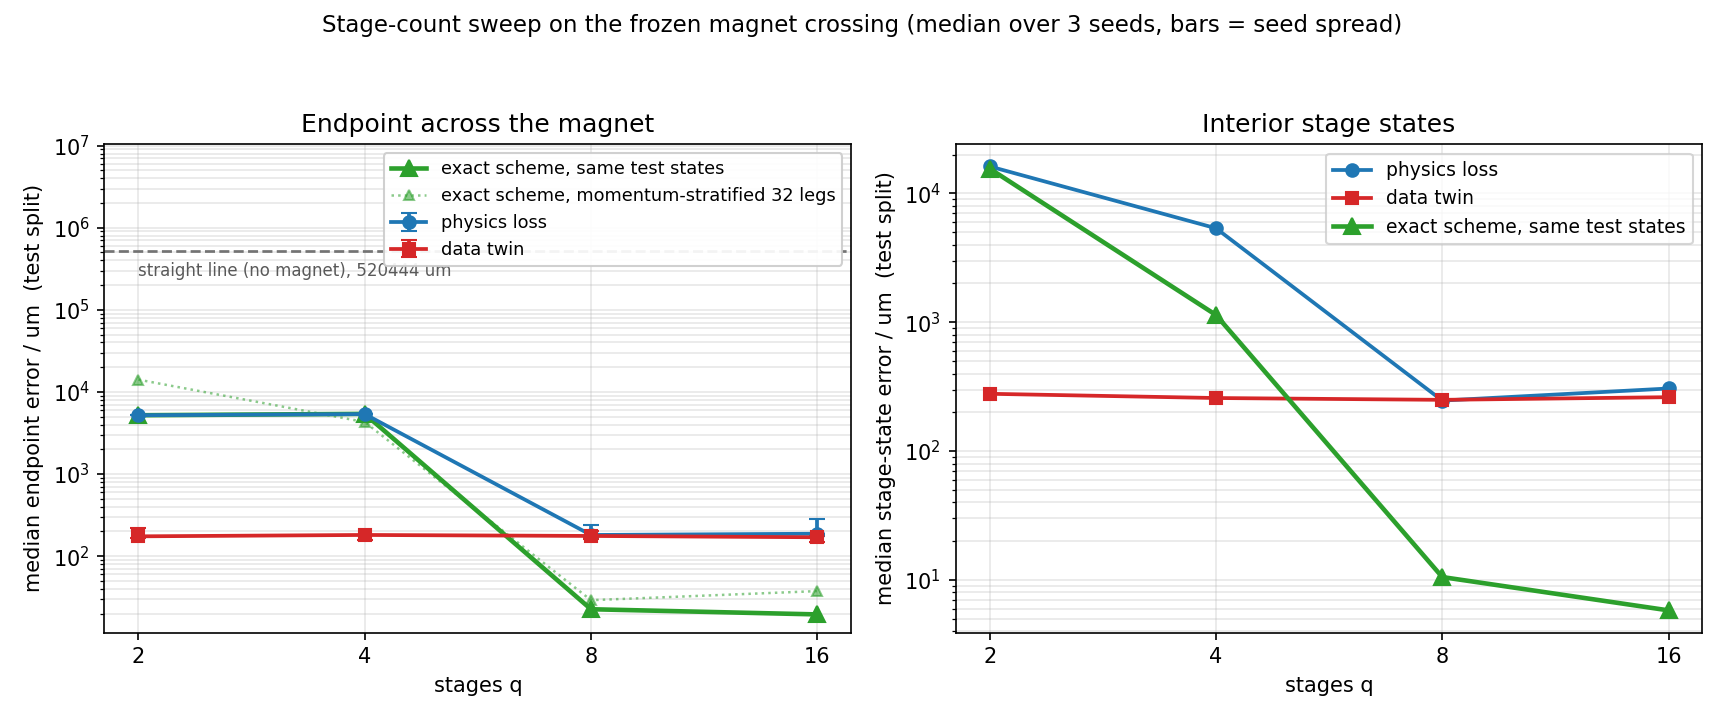

In [5]:
display(Image(filename=os.path.join(FIGURES, "error_vs_stages.png")))

### Reading the left panel

The blue curve sits **on** the green one at q = 2 and q = 4. Physics-loss median 5202 um
against a ceiling of 5198 um, and 5371 um against 5401 um: the network is reproducing the
exact solution of the coarse scheme to within a few parts in a thousand. At those stage
counts the training is not the problem and the network is not the problem - the discretised
equations themselves are 5 mm wrong, and a network that satisfies them faithfully inherits
that error exactly. This is the cleanest statement the experiment makes: **at q = 2 and 4
the physics loss is scheme-limited, and it is achieving its ceiling rather than falling
short of it.**

At q = 8 the two curves separate. The ceiling drops to 23 um while the network lands at
181 um, an order of magnitude above it. From q = 8 onward the scheme has stopped being the
limiter and something else has taken over. The red curve says what that something is: the
data twin, which never sees the scheme, is flat at 170-180 um across every q. The physics
network at q = 8 and 16 has simply arrived at the same floor as its supervised twin, and
that floor is a property of the 4x50 network and the L-BFGS protocol on this leg, not of
the discretisation.

Going from q = 8 to q = 16 therefore buys nothing at the endpoint, even though it halves
the scheme's own error again. Both panels are already flat there.

### Reading the right panel

The endpoint is one of the q + 1 states the network emits; the other q are interior stage
states that nothing downstream consumes, but which the physics loss is written in terms of.
Their error follows the endpoint story at q = 2 and 4 (scheme-limited, 16 mm and 5.4 mm)
and then lands on the same ~250-300 um network floor at q = 8 and 16, while the exact
scheme keeps improving to 10 um and 5.8 um. The gap between green and blue on the right at
large q is the same network floor seen from the inside.

## 4. Did the runs actually converge?

Every run is trained to a genuine stall - L-BFGS restarts until two consecutive restarts
each improve the loss by less than 1% - and then a **confirmation pass** with a fresh
optimiser, which counts as converged only if it re-stalls within two restarts with the
endpoint medians unchanged. A run that has not converged is never pooled into the medians
above.

Eight of the twenty-four did not converge on the first submission: six physics runs
(all three seeds at q = 4 and all three at q = 8) hit the shared driver's default
150-restart cap without ever stalling, and two q = 16 physics runs re-stalled but with
their endpoint medians still moving. All eight were resumed from their checkpoints with
`--outer-cap 400` and converged within a handful of further restarts; a larger cap changes
nothing for the runs that had already stalled below it, so the grid is uniform.

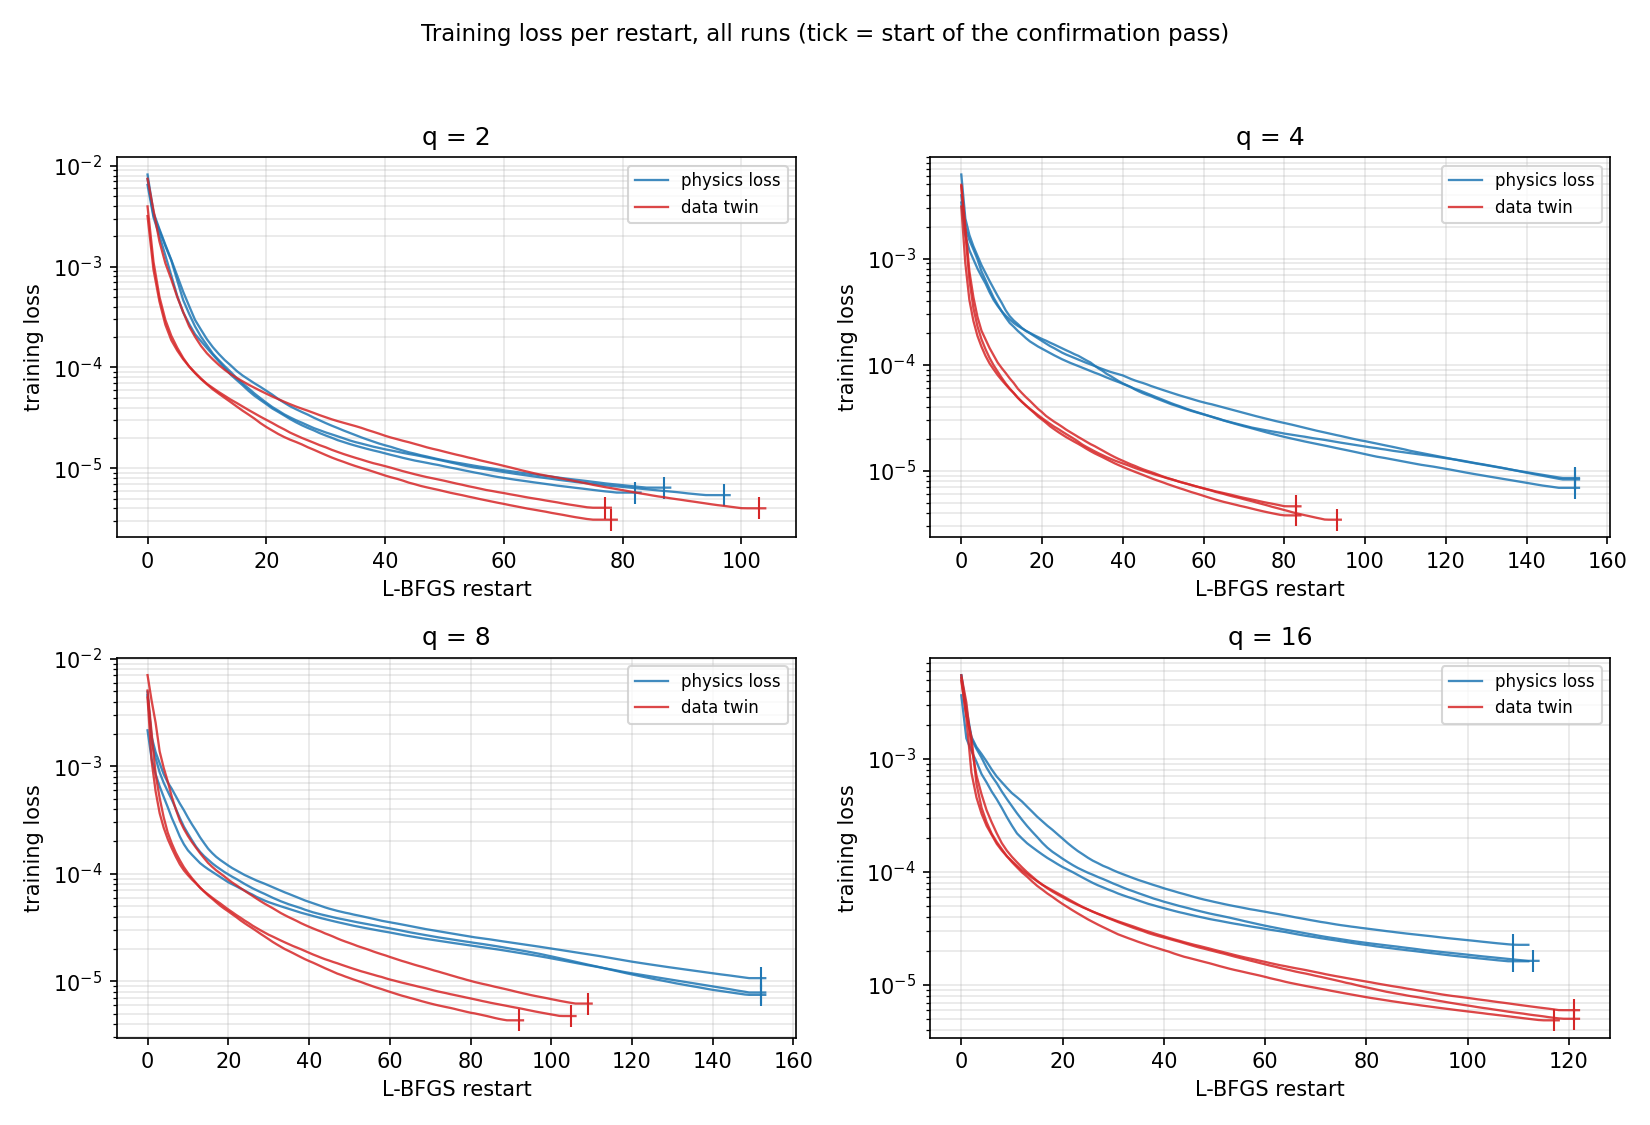

In [6]:
display(Image(filename=os.path.join(FIGURES, "convergence.png")))

In [7]:
summary.groupby(["q", "mode"]).agg(
    n=("seed", "count"),
    converged=("converged", "sum"),
    restarts_min=("restarts", "min"),
    restarts_max=("restarts", "max"),
    wall_min_med=("wall_s", lambda s: round(s.median() / 60, 1)),
    final_loss_med=("final_loss", "median"),
)

n  converged  restarts_min  restarts_max  wall_min_med  final_loss_med
q  mode                                                                           
2  data     3          3            79           105           5.2        0.000004
   physics  3          3            84            99           5.9        0.000006
4  data     3          3            85            95           4.5        0.000004
   physics  3          3           154           154          17.5        0.000008
8  data     3          3            94           111           8.5        0.000005
   physics  3          3           154           154          20.5        0.000008
16 data     3          3           119           123          11.1        0.000005
   physics  3          3           113           115          14.7        0.000016

The physics loss needs about 154 restarts at q = 4 and q = 8 and about 113 at q = 16. It
is worth noticing that **q = 16 is not the hard case**: despite emitting 68 numbers per
sample instead of 36, it stalls in fewer restarts and less wall time than q = 8. The
hardest optimisation in the grid is the one where the scheme's residual is large and
almost flat - q = 4, whose loss curve grinds down through two decades and is still moving
at restart 150.

## 5. The anchor: does q = 8 reproduce the verified baseline?

The q = 8 physics runs here are, by construction, `S2b_One_step_network_v2` run again through
the shared driver: the same dataset arrays (checked bitwise in section 1), the same
protocol, the same three seeds. The one difference is one BLAS thread instead of four,
which changes the last bits of every reduction and so cannot reproduce the numbers exactly
- only the range. v2's converged physics runs landed at 177-235 um and its data twin at
162-208 um.

In [8]:
q8 = summary[summary["q"] == 8][["mode", "seed", "test_endpoint_med_um",
                                  "test_stage_med_um", "restarts", "converged"]]
print("v2 baseline:  physics 177-235 um   data twin 162-208 um")
q8.round(1)

v2 baseline:  physics 177-235 um   data twin 162-208 um


,mode,seed,test_endpoint_med_um,test_stage_med_um,restarts,converged
12,data,0,176.0,240.6,94,True
13,data,1,161.8,249.8,107,True
14,data,2,204.1,282.5,111,True
15,physics,0,180.9,246.5,154,True
16,physics,1,164.7,228.0,154,True
17,physics,2,240.1,303.7,154,True


## 6. Verdict

* **The physics network achieves its ceiling wherever the ceiling is the limit.** At q = 2
  and q = 4 it lands within 0.1% and 0.6% of the exact scheme's own error on the same
  states. It is not failing to learn; it is faithfully learning equations that are wrong
  by 5 mm.
* **The scheme stops being the limiter between q = 4 and q = 8.** The ceiling falls from
  5401 um to 23 um there, crossing below the network's own floor. For q >= 8 the limiting
  factor is the 4x50 network and the optimiser, not the discretisation.
* **q = 8 and q = 16 share the same floor.** Physics 181 um [165-240] against 187 um
  [186-280]; the seed ranges overlap almost completely and the medians differ by 3%, far
  inside the spread. Doubling the stages past 8 costs 68 outputs per sample and buys
  nothing at the endpoint.
* **q = 8 is the working point**: the smallest stage count at which the scheme is no longer
  what limits the answer.
* **The floor is ~170-190 um and it belongs to the network.** The data twin, which never
  touches the scheme, sits at 170-180 um at every q including q = 2 - the strongest
  evidence that this number is about model capacity and optimisation, not discretisation.
  Lowering it is a question about width, depth or protocol, and that is the next
  experiment.